<h1>Estimation d’une provision pour dépréciation durable (PDD)<br>
et construction d’un modèle point</h1>

<p><strong>Membres du groupe :</strong></p>
<ul>
    <li><strong>DIOUF</strong> Salimata</li>
    <li><strong>KOUAME</strong> Christ Ange Dylan</li>
    <li><strong>OUATTARA</strong> Aboubakar</li>
    <li><strong>OUATTARA</strong> Souleymane</li>
</ul>

<hr>

<p><strong>Remarques générales :</strong></p>
<ul>
    <li>
        Dans la partie 3 du projet, le vecteur de pondération des actifs est noté 
        <strong>$W$</strong>, la lettre $\alpha$ étant déjà utilisée pour le critère de dépréciation.
    </li>
    <li>
        Au vu de la complexité des fonctions implémentées, du volume des simulations 
        et du nombre important de résultats graphiques à produire, les paramètres 
        numériques (nombre de simulations et nombre de pas de discrétisation) ont été 
        choisis afin de trouver un compromis entre précision et efficacité.
    </li>
    <li>
        Le temps d’exécution total du notebook complet est d’environ 
        <strong>22 minutes</strong> sur notre configuration de test.
    </li>
    <li>
        Dans l’ensemble du script, la seed aléatoire est fixée à <strong>42</strong> afin 
        d’assurer la reproductibilité des résultats.
    </li>
</ul>


# I) Un actif et une seule période

Importation librairies

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import time

Methode Naïve

In [2]:
def schema_euler_mc(
    n_sim, n_steps, dt,
    r0, S0,
    gamma, b,
    sigma_r, sigma, rho,
    Sa, alpha
):
    """
    Schéma d'Euler-Maruyama avec simulation des browniens
    via la matrice de variance–covariance et Cholesky.
    """

    # Matrice variance–covariance

    V = np.array([
        [sigma**2,rho * sigma * sigma_r],
        [rho * sigma * sigma_r, sigma_r**2]
    ])

    # Cholesky
    L = np.linalg.cholesky(V)


    # Initialisation

    r = np.zeros((n_sim, n_steps + 1))
    S = np.zeros((n_sim, n_steps + 1))
    r[:, 0] = r0
    S[:, 0] = S0


    # Simulation

    for t in range(n_steps):

        # Gaussiennes indépendantes
        Z = np.random.normal(size=(2, n_sim))

        # Incréments corrélés
        dW = np.sqrt(dt) * (np.dot(L, Z))

        dW_S = dW[0]
        dW_r = dW[1]

        # Vasicek
        r[:, t+1] = r[:, t] + gamma*(b - r[:, t])*dt + dW_r

        # Actif risqué
        S[:, t+1] = S[:, t] * (1 + r[:, t]*dt + dW_S)


    # Barrière sur les 6 derniers mois

    idx_6m = (n_steps // 2) + 1
    sup_6m = np.max(S[:, idx_6m:], axis=1)

    prob_no_cross = np.mean(
        (sup_6m <= Sa) & (S[:, -1] <= alpha * Sa)
    )

    return r, S, sup_6m, prob_no_cross


Methode Raffinée

In [3]:
import numpy as np

def methode_raf_from_S(
    S, sigma, Sa, alpha, T, n_steps, seed=None
):
    """
    Méthode raffinée  (tirage U à chaque pas), optimisée :
      - S est déjà simulé (shape: (n_sim, n_steps+1))
      - On applique le pont brownien sur les 6 derniers mois, intervalle par intervalle
      - crossed_barrier_6m mis à jour au fil de l'eau

    Retour:
      prob_survive, cond1, cond2
    """
    rng = np.random.default_rng(seed)

    n_sim = S.shape[0]
    dt = T / n_steps
    idx_6m = n_steps // 2

    # Pré-calculs (gros gain)
    logS = np.log(S)
    logSa = np.log(Sa)

    crossed = np.zeros(n_sim, dtype=bool)      # True si franchi pendant les 6 derniers mois
    alive = ~crossed                           # alias pour lisibilité

    # Boucle uniquement sur la fenêtre utile (6 derniers mois)
    for t in range(idx_6m, n_steps):
        if not alive.any():
            break

        # Trajectoires encore vivantes à ce pas
        i_alive = alive

        # Si une extrémité discrète est déjà >= Sa, franchissement certain
        above = i_alive & ((S[:, t] >= Sa) | (S[:, t+1] >= Sa))
        if above.any():
            crossed[above] = True
            alive = ~crossed
            if not alive.any():
                break

        # Pour le pont brownien, on ne garde que celles encore vivantes
        # et dont les 2 extrémités sont < Sa (sinon la formule n'est pas applicable proprement)
        eligible = alive & (S[:, t] < Sa) & (S[:, t+1] < Sa)
        if not eligible.any():
            continue

        # Calcul vectorisé des proba de franchissement pour les "eligible"
        a = logSa - logS[eligible, t]
        b = logSa - logS[eligible, t+1]

        # Proba de franchissement (TA formule)
        p_cross = np.exp(-2.0 * a * b / (sigma**2 * dt))
        p_cross = np.clip(p_cross, 0.0, 1.0)

        # Tirage U uniquement pour les eligible
        U = rng.uniform(0.0, 1.0, size=p_cross.size)
        hit = U < p_cross

        # Mettre à jour crossed
        idx_elig = np.flatnonzero(eligible)
        crossed[idx_elig[hit]] = True
        alive = ~crossed

    cond1 = ~crossed
    cond2 = S[:, -1] <= alpha * Sa
    prob_survive = np.mean(cond1 & cond2)

    return prob_survive, cond1, cond2


Fonction de calcul de PDD1

In [4]:
import numpy as np

def pdd_une_periode_from_S(
    methode,        # "naive" ou "rafinee"
    n_sim,
    n_steps,
    r0, S0,
    gamma, b, sigma_r, sigma, rho,
    Sa, alpha,
    seed=None
):
    dt = 1.0 / n_steps
    omega = Sa
    rng = np.random.default_rng(seed)

    # 1) Simulation UNIQUE (Euler)
    _, S, _, _ = schema_euler_mc(
        n_sim, n_steps, dt,
        r0, S0,
        gamma, b, sigma_r, sigma, rho,
        Sa, alpha
    )

    # 2) Condition terminale (commune)
    cond_terminal = (S[:, -1] <= alpha * Sa)

    # 3) Condition barrière
    if methode == "naive":
        idx_6m_naive = (n_steps // 2) + 1
        sup_6m = np.max(S[:, idx_6m_naive:], axis=1)
        cond_barriere = (sup_6m <= Sa)

    else:  # "rafinee" - TA logique pas à pas
        idx_6m = n_steps // 2
        logS = np.log(S)
        logSa = np.log(Sa)

        crossed = np.zeros(n_sim, dtype=bool)
        alive = ~crossed

        for t in range(idx_6m, n_steps):
            if not alive.any():
                break

            # franchissement certain si un point discret est déjà >= Sa
            above = alive & ((S[:, t] >= Sa) | (S[:, t+1] >= Sa))
            if above.any():
                crossed[above] = True
                alive = ~crossed
                if not alive.any():
                    break

            # éligibles au test pont : encore vivants ET deux extrémités sous Sa
            eligible = alive & (S[:, t] < Sa) & (S[:, t+1] < Sa)
            if not eligible.any():
                continue

            a = logSa - logS[eligible, t]
            b_ = logSa - logS[eligible, t+1]

            p_cross = np.exp(-2.0 * a * b_ / (sigma**2 * dt))
            p_cross = np.clip(p_cross, 0.0, 1.0)

            U = rng.uniform(0.0, 1.0, size=p_cross.size)
            hit = U < p_cross

            idx_elig = np.flatnonzero(eligible)
            crossed[idx_elig[hit]] = True
            alive = ~crossed

        cond_barriere = ~crossed

    # 4) Pertes
    cond = cond_barriere & cond_terminal
    ST = S[:, -1]
    loss = np.where(cond, omega - ST, 0.0)
    loss = np.maximum(loss, 0.0)

    return np.mean(loss), loss


Comparaison et convergence

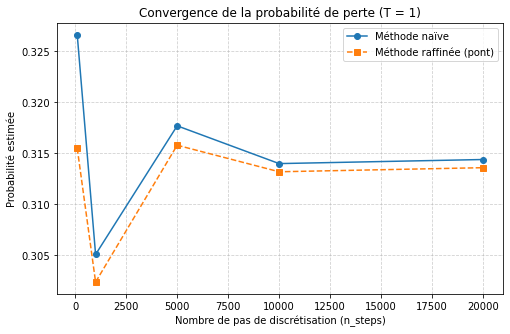

In [5]:
# Fixer la seed pour reproductibilité
np.random.seed(42)

# Paramètres
r0 = 0.02
b = 0.025
gamma = 0.2
sigma_r = 0.01
sigma = 0.3
Sa = 110
S0 = 100
alpha = 0.8
rho = 0.1

T_total = 1
n_sim = 10_000

# Liste des pas
n_steps_list = [100, 1000, 5000, 10000, 20000]

prob_naive_list = []
prob_rafinee_list = []

for n_steps in n_steps_list:
    dt = T_total / n_steps

    # Simulation UNIQUE
    _, S, _, _ = schema_euler_mc(
        n_sim, n_steps, dt,
        r0, S0,
        gamma, b,
        sigma_r, sigma, rho,
        Sa, alpha
    )

    # Méthode naïve
    sup_6m = np.max(S[:, (n_steps // 2) + 1:], axis=1)
    cond_naive = (sup_6m <= Sa) & (S[:, -1] <= alpha * Sa)
    prob_naive_list.append(np.mean(cond_naive))

    # Méthode raffinée
    idx_6m = n_steps // 2
    logS = np.log(S)
    logSa = np.log(Sa)

    crossed = np.zeros(n_sim, dtype=bool)
    alive = ~crossed

    # boucle uniquement sur les 6 derniers mois
    for t in range(idx_6m, n_steps):
        if not alive.any():
            break

        # franchissement certain si un point discret dépasse déjà Sa
        above = alive & ((S[:, t] >= Sa) | (S[:, t+1] >= Sa))
        if above.any():
            crossed[above] = True
            alive = ~crossed
            if not alive.any():
                break

        # éligibles au test pont : vivants et deux extrémités sous Sa
        eligible = alive & (S[:, t] < Sa) & (S[:, t+1] < Sa)
        if not eligible.any():
            continue

        a = logSa - logS[eligible, t]
        b_ = logSa - logS[eligible, t+1]

        p_cross = np.exp(-2.0 * a * b_ / (sigma**2 * dt))
        p_cross = np.clip(p_cross, 0.0, 1.0)

        U = np.random.uniform(size=p_cross.size)
        hit = U < p_cross

        idx_elig = np.flatnonzero(eligible)
        crossed[idx_elig[hit]] = True
        alive = ~crossed

    cond1 = ~crossed
    cond2 = (S[:, -1] <= alpha * Sa)

    cond_rafinee = cond1 & cond2
    prob_rafinee_list.append(np.mean(cond_rafinee))


# GRAPHIQUE
plt.figure(figsize=(8, 5))
plt.plot(n_steps_list, prob_naive_list, marker='o', label="Méthode naïve")
plt.plot(n_steps_list, prob_rafinee_list, marker='s', linestyle='--', label="Méthode raffinée (pont)")
plt.xlabel("Nombre de pas de discrétisation (n_steps)")
plt.ylabel("Probabilité estimée")
plt.title("Convergence de la probabilité de perte (T = 1)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


Le graphique montre que, pour un faible nombre de pas, la méthode naïve surestime la probabilité de perte par rapport à la méthode raffinée. Ce comportement est normal, car la méthode naïve ne détecte les franchissements de barrière qu’aux dates discrètes et ignore ceux qui ont lieu entre deux pas de temps. Elle considère donc à tort certaines trajectoires comme sûres, ce qui conduit à une estimation trop optimiste.

La méthode raffinée, grâce au pont brownien, corrige ce biais en prenant en compte les franchissements intermédiaires. Elle fournit ainsi des estimations plus prudentes et plus stables. Lorsque le nombre de pas augmente, les deux méthodes convergent, ce qui confirme que le biais de discrétisation diminue avec une grille plus fine. En pratique, cela montre que la méthode raffinée est préférable dès que la discrétisation est limitée.

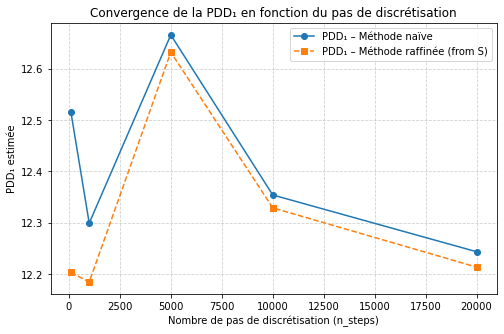

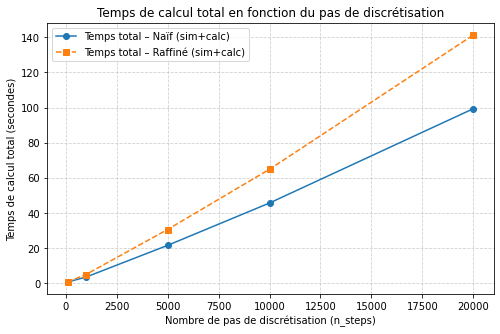

In [6]:
# Paramètres de base
r0 = 0.02
b = 0.025
gamma = 0.2
sigma_r = 0.01
sigma = 0.3
Sa = 110
S0 = 100
alpha = 0.8
rho = 0.1

T_total = 1
n_sim = 10_000
n_steps_list = [100, 1000, 5000, 10000, 20000]

BASE_SEED = 42

PDD_naive = []
PDD_rafinee = []
time_naive = []
time_rafinee = []

for n_steps in n_steps_list:
    dt = T_total / n_steps

    # 1) Simulation UNIQUE
    sim_seed = BASE_SEED + 1000 + n_steps
    np.random.seed(sim_seed)  # pour rendre schema_euler_mc reproductible

    t0 = time.perf_counter()
    _, S, _, _ = schema_euler_mc(
        n_sim, n_steps, dt,
        r0, S0,
        gamma, b,
        sigma_r, sigma, rho,
        Sa, alpha
    )
    t1 = time.perf_counter()
    t_sim = t1 - t0

    ST = S[:, -1]                 # on réutilise
    omega = Sa

    # 2) Naïf : calcul de la perte / PDD
    t0 = time.perf_counter()
    sup_6m = np.max(S[:, (n_steps // 2) + 1:], axis=1)
    cond_naive = (sup_6m <= Sa) & (ST <= alpha * Sa)
    loss_naive = np.maximum(np.where(cond_naive, omega - ST, 0.0), 0.0)
    PDD_naive.append(np.mean(loss_naive))
    t1 = time.perf_counter()
    time_naive.append((t1 - t0) + t_sim)   # simulation + post-traitement

    # 3) Raffinée : cond1 via methode_raf_from_S puis perte / PDD
    t0 = time.perf_counter()
    raf_seed = BASE_SEED + 2000 + n_steps
    _, cond1, cond2 = methode_raf_from_S(
        S, sigma, Sa, alpha, T_total, n_steps, seed=raf_seed
    )
    cond_raf = cond1 & cond2
    loss_raf = np.maximum(np.where(cond_raf, omega - ST, 0.0), 0.0)
    PDD_rafinee.append(np.mean(loss_raf))
    t1 = time.perf_counter()
    time_rafinee.append((t1 - t0) + t_sim) # simulation + post-traitement

# GRAPHIQUE PDD
plt.figure(figsize=(8, 5))
plt.plot(n_steps_list, PDD_naive, marker='o', label="PDD₁ – Méthode naïve")
plt.plot(n_steps_list, PDD_rafinee, marker='s', linestyle='--', label="PDD₁ – Méthode raffinée (from S)")
plt.xlabel("Nombre de pas de discrétisation (n_steps)")
plt.ylabel("PDD₁ estimée")
plt.title("Convergence de la PDD₁ en fonction du pas de discrétisation")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# GRAPHIQUE TEMPS
plt.figure(figsize=(8, 5))
plt.plot(n_steps_list, time_naive, marker='o', label="Temps total – Naïf (sim+calc)")
plt.plot(n_steps_list, time_rafinee, marker='s', linestyle='--', label="Temps total – Raffiné (sim+calc)")
plt.xlabel("Nombre de pas de discrétisation (n_steps)")
plt.ylabel("Temps de calcul total (secondes)")
plt.title("Temps de calcul total en fonction du pas de discrétisation")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


Le premier graphique montre que, quelle que soit la discrétisation, la méthode naïve donne des valeurs de PDD₁ légèrement plus élevées que la méthode raffinée. Cela traduit un biais lié au fait que la méthode naïve ne capte pas correctement les franchissements entre deux dates. La méthode raffinée corrige ce biais via le pont brownien, ce qui conduit à une estimation plus réaliste. Lorsque le nombre de pas augmente, les deux méthodes convergent, ce qui confirme la cohérence du modèle.

Le second graphique met en évidence le coût numérique de cette amélioration. La méthode raffinée est systématiquement plus lente, car elle nécessite des calculs supplémentaires sur chaque intervalle. Le temps de calcul augmente fortement avec n_steps pour les deux méthodes, mais plus rapidement pour la raffinée. En pratique, cela met en évidence un compromis entre précision et temps de calcul : la méthode raffinée est plus fiable, mais plus coûteuse, tandis que la méthode naïve est plus rapide au prix d’un biais.

# II) Un seul actif et plusieurs périodes

##  1 ) Estimation de la PDD

Definition fonction de calcul

In [7]:
def pdd_multi_periode(
    methode,        # "naive" ou "rafinee"
    T,              # nombre d'années
    n_sim,
    n_steps,
    r0, S0,
    gamma, b, sigma_r, sigma, rho,
    Sa, alpha,
    seed_sim=None,
    seed_raf=None
):
    """
    Calcule la PDD_T sur T périodes (années) en simulant UNE SEULE fois la trajectoire,
    puis en appliquant la logique de perte période par période.

    - methode="naive": barrière discrète via max sur la fenêtre ]k-0.5, k]
    - methode="rafinee": barrière continue via pont brownien pas à pas
    """
    dt = 1.0 / n_steps
    N_total = T * n_steps

    # Simulation UNIQUE sur tout l'horizon
    if seed_sim is not None:
        np.random.seed(seed_sim)

    _, S_full, _, _ = schema_euler_mc(
        n_sim, N_total, dt,
        r0, S0,
        gamma, b, sigma_r, sigma, rho,
        Sa, alpha
    )

    # Comptabilité / pertes (vectorisées)
    omega = np.full(n_sim, Sa, dtype=float)
    perte_actualisee = np.zeros(n_sim, dtype=float)
    loss_cumule = np.zeros(n_sim, dtype=float)

    # Pré-calcul pour raffinée
    if methode == "rafinee":
        logS_full = np.log(S_full)
        logSa = np.log(Sa)
        rng = np.random.default_rng(seed_raf)

    for k in range(1, T + 1):
        # indices de la période k : (k-1)*n_steps -> k*n_steps
        start = (k - 1) * n_steps
        end   = k * n_steps

        # S à la fin de la période
        S_end = S_full[:, end]

        # condition terminale (comme avant)
        cond_terminal = (S_end <= alpha * Sa)

        # fenêtre des 6 derniers mois de la période
        idx_6m = start + n_steps // 2

        # --- condition barrière ---
        if methode == "naive":
            # max discret sur les points simulés
            sup_6m = np.max(S_full[:, idx_6m:end + 1], axis=1)
            cond_barriere = (sup_6m <= Sa)

        else:  # "rafinee" : TA logique pas à pas
            crossed = np.zeros(n_sim, dtype=bool)
            alive = ~crossed

            for t in range(idx_6m, end):
                if not alive.any():
                    break

                # franchissement certain si un point discret est déjà >= Sa
                above = alive & ((S_full[:, t] >= Sa) | (S_full[:, t+1] >= Sa))
                if above.any():
                    crossed[above] = True
                    alive = ~crossed
                    if not alive.any():
                        break

                eligible = alive & (S_full[:, t] < Sa) & (S_full[:, t+1] < Sa)
                if not eligible.any():
                    continue

                a = logSa - logS_full[eligible, t]
                b_ = logSa - logS_full[eligible, t+1]

                p_cross = np.exp(-2.0 * a * b_ / (sigma**2 * dt))
                p_cross = np.clip(p_cross, 0.0, 1.0)

                U = rng.uniform(0.0, 1.0, size=p_cross.size)
                hit = U < p_cross

                idx_elig = np.flatnonzero(eligible)
                crossed[idx_elig[hit]] = True
                alive = ~crossed

            cond_barriere = ~crossed

        # condition globale
        cond = cond_barriere & cond_terminal

        # perte de période (même logique que toi)
        loss = np.where(cond, omega - S_end, 0.0)
        loss = np.maximum(loss, 0.0)

        loss_cumule += loss
        perte_actualisee += np.exp(-r0 * (k - 1)) * loss

        omega -= loss

    PDD = np.mean(perte_actualisee)
    return PDD, loss_cumule


Estimation PDD sur differentes périodes

In [8]:
def run_PDD_over_T(
    T_list,
    n_sim,
    n_steps,
    r0, S0,
    gamma, b, sigma_r, sigma, rho,
    Sa, alpha,
    base_seed=42
):
    print("\n=== PDD_T pour différents horizons ===")
    print("T\tPDD_naive\t\tPDD_rafinee")

    results = []

    for T in T_list:
        # même seed_sim pour générer exactement le même S_full
        seed_sim = base_seed + 1000 + 10*T
        # seed séparée pour le tirage U du pont brownien
        seed_raf = base_seed + 2000 + 10*T

        PDD_naive, _ = pdd_multi_periode(
            methode="naive",
            T=T,
            n_sim=n_sim,
            n_steps=n_steps,
            r0=r0, S0=S0,
            gamma=gamma, b=b,
            sigma_r=sigma_r, sigma=sigma, rho=rho,
            Sa=Sa, alpha=alpha,
            seed_sim=seed_sim
        )

        PDD_raf, _ = pdd_multi_periode(
            methode="rafinee",
            T=T,
            n_sim=n_sim,
            n_steps=n_steps,
            r0=r0, S0=S0,
            gamma=gamma, b=b,
            sigma_r=sigma_r, sigma=sigma, rho=rho,
            Sa=Sa, alpha=alpha,
            seed_sim=seed_sim,   # même trajectoire
            seed_raf=seed_raf    # tirage U propre au raffinement
        )

        results.append((T, PDD_naive, PDD_raf))
        print(f"{T}\t{PDD_naive:.4f}\t\t{PDD_raf:.4f}")

    return results


In [9]:
# Paramètres de base
r0 = 0.02
b = 0.025
gamma = 0.2
sigma_r = 0.01
sigma = 0.3
Sa = 110
S0 = 100
alpha = 0.8
rho = 0.1

T_list = [1, 2, 5, 10, 15]

results = run_PDD_over_T(
    T_list=T_list,
    n_sim=10000,
    n_steps=100,
    r0=r0,
    S0=S0,
    gamma=gamma,
    b=b,
    sigma_r=sigma_r,
    sigma=sigma,
    rho=rho,
    Sa=Sa,
    alpha=alpha,
    base_seed=42   # seed centrale pour tout l'expérience
)



=== PDD_T pour différents horizons ===
T	PDD_naive		PDD_rafinee
1	12.9382		12.6601
2	21.0830		20.8585
5	35.3121		35.1549
10	47.2113		47.0679
15	53.7075		53.6179


Ce tableau montre que la PDD augmente naturellement avec l’horizon T, ce qui est normal puisque le risque s’accumule dans le temps. Plus on regarde loin, plus les pertes potentielles sont importantes.

On observe aussi que, pour tous les horizons, la méthode naïve donne une PDD légèrement plus élevée que la méthode raffinée. Cela s’explique par le fait que la discrétisation grossière sous-estime les franchissements réels de la barrière entre deux dates. En pratique, certaines trajectoires qui franchissent la barrière en continu ne sont pas détectées.

Ces trajectoires sont alors à tort considérées comme « survivantes », ce qui augmente artificiellement le nombre de défauts détectés ensuite, et donc la PDD. La méthode raffinée corrige ce biais en prenant en compte les franchissements intermédiaires via le pont brownien, ce qui conduit à des estimations plus fiables.

L’écart reste toutefois limité, ce qui montre que la méthode naïve reste utilisable pour de grands horizons, mais au prix d’un léger biais pessimiste.

Evolution de la PDD en fonction des paramètres

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_PDD_sensitivity_1D(
    T_list,
    sigma_grid,
    r0_grid,
    r0_fixed,
    sigma_fixed,
    n_sim,
    n_steps,
    S0,
    gamma, b, sigma_r,
    rho,
    Sa, alpha,
    base_seed=42
):
    """
    Trace les graphes comparatifs PDD_T naïf vs raffiné
    - PDD vs sigma (r0 fixé)
    - PDD vs r0 (sigma fixé)

    Optimisations / bonnes pratiques :
    - même seed_sim pour naïf et raffiné -> comparaison sur la même trajectoire
    - seed_raf séparé pour les tirages du pont brownien
    - résultats reproductibles
    """

    def compute_pair_PDD(T, r0_val, sigma_val, tag):
        """
        Calcule (PDD_naive, PDD_rafinee) pour un couple (r0, sigma),
        sur la même trajectoire S_full via seed_sim identique.
        """
        seed_sim = base_seed + 100_000 + 1000*tag + 10*T
        seed_raf = base_seed + 200_000 + 1000*tag + 10*T

        PDD_n, _ = pdd_multi_periode(
            methode="naive",
            T=T,
            n_sim=n_sim,
            n_steps=n_steps,
            r0=r0_val, S0=S0,
            gamma=gamma, b=b,
            sigma_r=sigma_r, sigma=sigma_val, rho=rho,
            Sa=Sa, alpha=alpha,
            seed_sim=seed_sim
        )

        PDD_r, _ = pdd_multi_periode(
            methode="rafinee",
            T=T,
            n_sim=n_sim,
            n_steps=n_steps,
            r0=r0_val, S0=S0,
            gamma=gamma, b=b,
            sigma_r=sigma_r, sigma=sigma_val, rho=rho,
            Sa=Sa, alpha=alpha,
            seed_sim=seed_sim,   # même trajectoire
            seed_raf=seed_raf
        )

        return PDD_n, PDD_r

    for T in T_list:

        # PDD en fonction de sigma
        PDD_naive_sigma = np.zeros(len(sigma_grid))
        PDD_ref_sigma   = np.zeros(len(sigma_grid))

        for i, sig in enumerate(sigma_grid):
            # tag=i pour avoir des seeds différentes selon le point de grille
            pn, pr = compute_pair_PDD(T, r0_fixed, sig, tag=1000 + i)
            PDD_naive_sigma[i] = pn
            PDD_ref_sigma[i]   = pr

        # PDD en fonction de r0
        PDD_naive_r0 = np.zeros(len(r0_grid))
        PDD_ref_r0   = np.zeros(len(r0_grid))

        for j, r0_val in enumerate(r0_grid):
            pn, pr = compute_pair_PDD(T, r0_val, sigma_fixed, tag=2000 + j)
            PDD_naive_r0[j] = pn
            PDD_ref_r0[j]   = pr

        # GRAPHIQUES
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # PDD vs sigma
        axes[0].plot(sigma_grid, PDD_naive_sigma, marker='o', label="Naïf")
        axes[0].plot(sigma_grid, PDD_ref_sigma, marker='s', linestyle='--', label="Raffinée")
        axes[0].set_title(f"PDD_T en fonction de σ (T = {T})")
        axes[0].set_xlabel("Volatilité σ")
        axes[0].set_ylabel("PDD_T")
        axes[0].grid(True, linestyle="--", alpha=0.7)
        axes[0].legend()

        # PDD vs r0
        axes[1].plot(r0_grid, PDD_naive_r0, marker='o', label="Naïf")
        axes[1].plot(r0_grid, PDD_ref_r0, marker='s', linestyle='--', label="Raffinée")
        axes[1].set_title(f"PDD_T en fonction de r₀ (T = {T})")
        axes[1].set_xlabel("Taux initial r₀")
        axes[1].set_ylabel("PDD_T")
        axes[1].grid(True, linestyle="--", alpha=0.7)
        axes[1].legend()

        plt.suptitle(f"Sensibilité de la PDD — comparaison naïf vs raffiné (T = {T})", fontsize=14)
        plt.tight_layout()
        plt.show()


Comparaison performance des deux méthodes

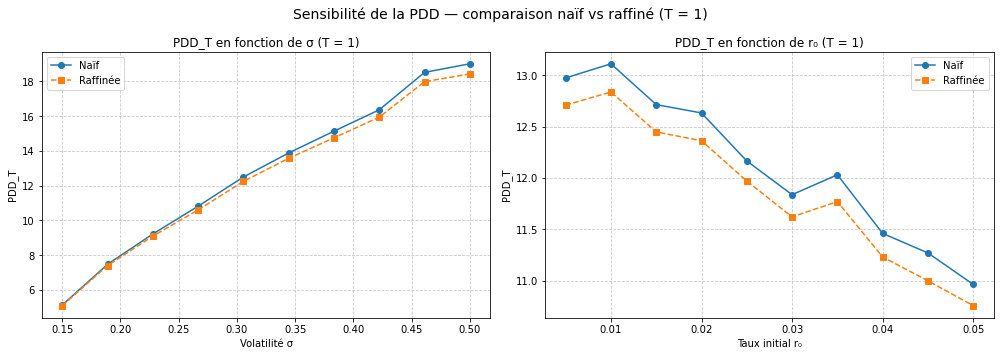

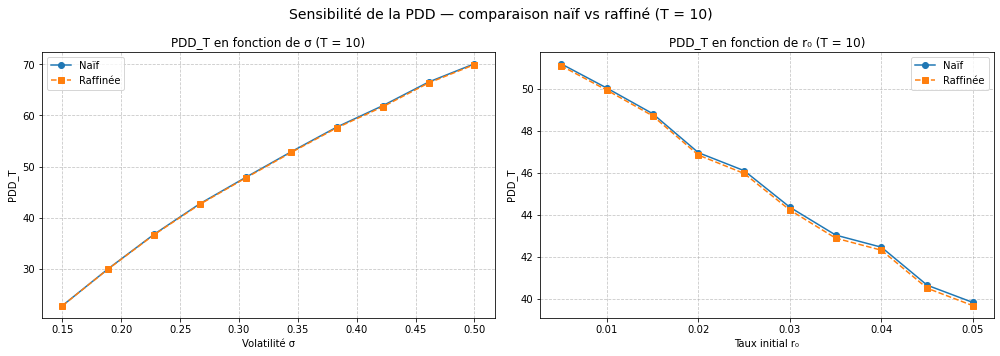

In [11]:
# Paramètres
r0 = 0.02
b = 0.025
gamma = 0.2
sigma_r = 0.01
sigma = 0.3
Sa = 110
S0 = 100
alpha = 0.8
rho = 0.1
n_sim = 10000

sigma_grid = np.linspace(0.15, 0.5, 10)
r0_grid = np.linspace(0.005, 0.05, 10)

plot_PDD_sensitivity_1D(
    T_list=[1, 10],
    sigma_grid=sigma_grid,
    r0_grid=r0_grid,
    r0_fixed=0.02,
    sigma_fixed=0.3,
    n_sim=n_sim,
    n_steps=100,
    S0=S0,
    gamma=gamma,
    b=b,
    sigma_r=sigma_r,
    rho=rho,
    Sa=Sa,
    alpha=alpha,
    base_seed=42
)


Avec 10 000 trajectoires mais seulement 100 pas de discrétisation sur tout l’horizon, on est dans un cadre où la grille est très grossière. On retrouve néanmoins les tendances économiques attendues : la PDD augmente fortement avec la volatilité σ (plus d’incertitude → plus de risque de franchissement et de perte), tandis qu’elle diminue globalement quand 
𝑟0 augmente (dérive plus favorable de l’actif → pertes attendues plus faibles).

Sur la comparaison naïf vs raffinée, l’écart est surtout visible à T=1 : la méthode naïve donne une PDD légèrement plus élevée. C’est cohérent avec une grille grossière : en ne regardant que les points discrets, la méthode naïve gère mal la contrainte de barrière sur la fenêtre des 6 derniers mois, ce qui introduit un biais. La méthode raffinée corrige en testant le franchissement entre deux dates via le pont brownien, et fournit une estimation plus “continue”. 

À T=10, les deux courbes deviennent quasiment confondues : sur un horizon long, la PDD résulte d’une accumulation de pertes sur plusieurs périodes, et l’impact marginal du raffinement intra-période devient faible par rapport au niveau total de risque. En pratique, le raffinement est surtout utile quand on veut une estimation précise à court terme sans augmenter drastiquement le nombre de pas.

## 2 ) Sensibilité PDD

Fonction de calcul de grecques

In [12]:
import numpy as np

def greek_pdd_fd(
    greek,              # "delta", "vega", "rho"
    methode,            # "naive" ou "rafinee"
    x_grid,             # valeurs du paramètre étudié
    h,                  # pas de différence finie
    n_sim, n_steps,
    r0, S0,
    gamma, b, sigma_r, sigma, rho,
    Sa, alpha,
    base_seed=42
):
    """
    Calcule un Greek de la PDD1 par différences finies centrées.
    Version adaptée à pdd_multi_periode() (y compris paramètres seed_sim/seed_raf).

    Optimisation:
    - Common Random Numbers: même seed_sim (et seed_raf) pour PDD_plus et PDD_minus
      -> Greeks beaucoup moins bruités.
    """
    greek_values = np.zeros(len(x_grid), dtype=float)

    for i, x in enumerate(x_grid):

        # paramètres "plus" / "moins"
        r0_p, r0_m = r0, r0
        S0_p, S0_m = S0, S0
        sigma_p, sigma_m = sigma, sigma

        if greek == "delta":
            S0_p, S0_m = x + h, x - h
        elif greek == "vega":
            sigma_p, sigma_m = x + h, x - h
        elif greek == "rho":
            r0_p, r0_m = x + h, x - h
        else:
            raise ValueError("Greek inconnu: choisir 'delta', 'vega' ou 'rho'.")

        # Seeds stables (même tirages pour + et -)
        seed_sim = base_seed + 100_000 + 10*i
        seed_raf = base_seed + 200_000 + 10*i

        # PDD(x+h)
        PDD_plus, _ = pdd_multi_periode(
            methode=methode,
            T=1,
            n_sim=n_sim,
            n_steps=n_steps,
            r0=r0_p, S0=S0_p,
            gamma=gamma, b=b,
            sigma_r=sigma_r, sigma=sigma_p, rho=rho,
            Sa=Sa, alpha=alpha,
            seed_sim=seed_sim,
            seed_raf=seed_raf if methode == "rafinee" else None
        )

        # PDD(x-h)
        PDD_minus, _ = pdd_multi_periode(
            methode=methode,
            T=1,
            n_sim=n_sim,
            n_steps=n_steps,
            r0=r0_m, S0=S0_m,
            gamma=gamma, b=b,
            sigma_r=sigma_r, sigma=sigma_m, rho=rho,
            Sa=Sa, alpha=alpha,
            seed_sim=seed_sim,  # même seed_sim
            seed_raf=seed_raf if methode == "rafinee" else None
        )

        greek_values[i] = (PDD_plus - PDD_minus) / (2.0 * h)

    return greek_values


Evolution des grecques

In [13]:
# Paramètres
r0 = 0.02
b = 0.025
gamma = 0.2
sigma_r = 0.01
sigma = 0.3
Sa = 110
S0 = 100
alpha = 0.8
rho = 0.1
n_sim = 5000
n_steps = 100


sigma_grid = np.linspace(0.15, 0.5, 10)
r0_grid    = np.linspace(0.005, 0.05, 10)
S0_grid    = np.linspace(80, 120, 10)

h_sigma = 0.01
h_r0    = 0.002
h_S0    = 1.0

# VEGA = d(PDD1)/d(sigma)
vega_naive = greek_pdd_fd(
    greek="vega",
    methode="naive",
    x_grid=sigma_grid,
    h=h_sigma,
    n_sim=n_sim, n_steps=n_steps,
    r0=r0, S0=S0,
    gamma=gamma, b=b, sigma_r=sigma_r,
    sigma=sigma, rho=rho,
    Sa=Sa, alpha=alpha,
    base_seed=42
)

vega_raf = greek_pdd_fd(
    greek="vega",
    methode="rafinee",
    x_grid=sigma_grid,
    h=h_sigma,
    n_sim=n_sim, n_steps=n_steps,
    r0=r0, S0=S0,
    gamma=gamma, b=b, sigma_r=sigma_r,
    sigma=sigma, rho=rho,
    Sa=Sa, alpha=alpha,
    base_seed=42
)

# RHO = d(PDD1)/d(r0)
rho_naive = greek_pdd_fd(
    greek="rho",
    methode="naive",
    x_grid=r0_grid,
    h=h_r0,
    n_sim=n_sim, n_steps=n_steps,
    r0=r0, S0=S0,
    gamma=gamma, b=b, sigma_r=sigma_r,
    sigma=sigma, rho=rho,
    Sa=Sa, alpha=alpha,
    base_seed=42
)

rho_raf = greek_pdd_fd(
    greek="rho",
    methode="rafinee",
    x_grid=r0_grid,
    h=h_r0,
    n_sim=n_sim, n_steps=n_steps,
    r0=r0, S0=S0,
    gamma=gamma, b=b, sigma_r=sigma_r,
    sigma=sigma, rho=rho,
    Sa=Sa, alpha=alpha,
    base_seed=42
)

# DELTA = d(PDD1)/d(S0)
delta_naive = greek_pdd_fd(
    greek="delta",
    methode="naive",
    x_grid=S0_grid,
    h=h_S0,
    n_sim=n_sim, n_steps=n_steps,
    r0=r0, S0=S0,
    gamma=gamma, b=b, sigma_r=sigma_r,
    sigma=sigma, rho=rho,
    Sa=Sa, alpha=alpha,
    base_seed=42
)

delta_raf = greek_pdd_fd(
    greek="delta",
    methode="rafinee",
    x_grid=S0_grid,
    h=h_S0,
    n_sim=n_sim, n_steps=n_steps,
    r0=r0, S0=S0,
    gamma=gamma, b=b, sigma_r=sigma_r,
    sigma=sigma, rho=rho,
    Sa=Sa, alpha=alpha,
    base_seed=42
)


Commentaires des resultats

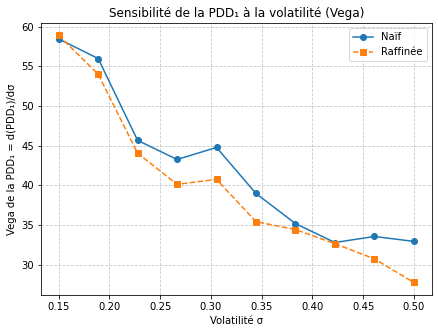

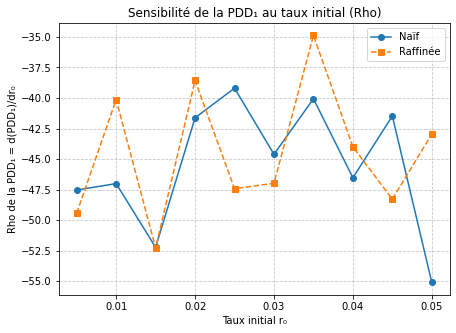

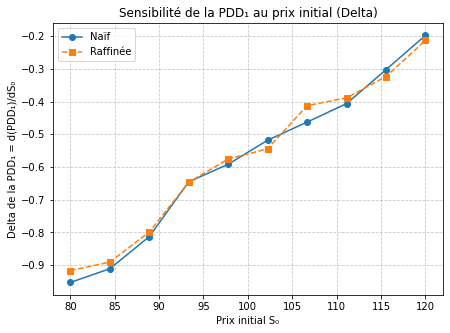

In [14]:
# VEGA : évolution vs sigma
plt.figure(figsize=(7, 5))
plt.plot(sigma_grid, vega_naive, marker='o', label="Naïf")
plt.plot(sigma_grid, vega_raf, marker='s', linestyle='--', label="Raffinée")
plt.xlabel("Volatilité σ")
plt.ylabel("Vega de la PDD₁ = d(PDD₁)/dσ")
plt.title("Sensibilité de la PDD₁ à la volatilité (Vega)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# RHO : évolution vs r0
plt.figure(figsize=(7, 5))
plt.plot(r0_grid, rho_naive, marker='o', label="Naïf")
plt.plot(r0_grid, rho_raf, marker='s', linestyle='--', label="Raffinée")
plt.xlabel("Taux initial r₀")
plt.ylabel("Rho de la PDD₁ = d(PDD₁)/dr₀")
plt.title("Sensibilité de la PDD₁ au taux initial (Rho)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# DELTA : évolution vs S0
plt.figure(figsize=(7, 5))
plt.plot(S0_grid, delta_naive, marker='o', label="Naïf")
plt.plot(S0_grid, delta_raf, marker='s', linestyle='--', label="Raffinée")
plt.xlabel("Prix initial S₀")
plt.ylabel("Delta de la PDD₁ = d(PDD₁)/dS₀")
plt.title("Sensibilité de la PDD₁ au prix initial (Delta)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()



# Delta en fonction de $S_0$.
Pour Delta, on observe que la dérivée $\frac{\partial \mathbb{E}[\lambda_0]}{\partial S_0}$ est strictement négative sur tout l’intervalle de valeurs de $S_0$, ce qui signifie que la PDD diminue lorsque le cours initial de l’actif augmente. Lorsque $S_0$ devient plus élevé relativement au prix d’acquisition $S_a$, la probabilité que l’actif termine sous le seuil de dépréciation $\alpha S_a$ se réduit, et la perte moyenne enregistrée est donc moins sensible à une variation supplémentaire de $S_0$. La courbe de Delta est néanmoins clairement croissante (tout en restant négative) : pour des niveaux faibles de $S_0$ (autour de 80–90), Delta est proche de $-0{,}9$, alors qu’elle remonte vers environ $-0{,}2$ lorsque $S_0$ atteint 120. En valeur absolue, la sensibilité de la PDD à $S_0$ est donc forte lorsque l’actif démarre proche de la zone de dépréciation, puis elle se réduit progressivement à mesure que $S_0$ s’éloigne du seuil critique. Enfin, les courbes issues des méthodes naïve et raffinée sont presque confondues, ce qui montre que la correction par pont brownien n’affecte que marginalement la dépendance de la PDD à $S_0$ et que les deux approches capturent la même structure de sensibilité.




# Vega en fonction de $\sigma$.

On observe que le vega de la PDD₁ (la sensibilité de la PDD₁ à $\sigma$) est positif partout, ce qui est attendu : augmenter la volatilité augmente la probabilité d’épisodes défavorables et donc la perte attendue.

Ce qui est intéressant ici, c’est que le vega diminue quand $\sigma$ augmente : l’impact marginal d’une hausse de volatilité est fort quand on part d’un régime “peu volatil” ($\sigma$ ≈ 15–20 %), puis il s’atténue quand le marché est déjà très volatil ($\sigma$ ≈ 45–50 %). En pratique, on peut l’interpréter comme un effet de saturation : quand $\sigma$ est déjà élevé, le scénario de perte devient déjà fréquent, donc rajouter encore de la volatilité augmente moins la PDD en relatif.

Enfin, la courbe naïve est globalement au-dessus de la raffinée : la méthode naïve tend donc à donner une sensibilité légèrement plus forte à $\sigma$. C’est cohérent avec le biais de discrétisation : si on gère moins bien les franchissements continus de la barrière, on peut amplifier artificiellement l’effet d’une variation de $\sigma$ sur la décision “défaut / non défaut”, et donc sur la PDD₁.


# Rho en fonction de $r_0$.

On observe que le rho de la PDD₁ est négatif sur toute la plage étudiée, ce qui signifie qu’une hausse du taux initial réduit la perte attendue. C’est cohérent économiquement : un taux plus élevé améliore en moyenne la dynamique du sous-jacent, ce qui diminue la probabilité d’atteindre la zone de défaut.

Les courbes restent cependant irrégulières, surtout pour la méthode naïve, ce qui reflète le bruit Monte Carlo inhérent au calcul par différences finies. La méthode raffinée apparaît globalement un peu plus stable, car elle corrige mieux les biais liés aux franchissements de barrière.

Enfin, l’ordre de grandeur du rho reste plus faible et plus instable que celui du vega, ce qui confirme que, dans ce modèle, la PDD est beaucoup plus sensible à la volatilité qu’au taux d’intérêt.



# III) Modèle Multi-actifs et modèle point (aggrégé)

Reamrque : Dans cette partie notons le veceurs des poids W , la lettre alpha étant déjà affectée au critère de dépréciation

## Question 4 : construction du modèle aggrégé

Construction matrice de correlations

In [15]:
def build_Gamma_Sigma(d):
    Gamma = np.eye(d+1)
    np.random.seed(42)
    for i in range(d):
        for j in range(i+1, d):
            Gamma[i, j] = np.random.uniform(0, 1)
        Gamma[i, d] = np.random.uniform(0, 0.2)

    Sigma0 = Gamma.T @ Gamma
    D = np.sqrt(np.diag(Sigma0))
    Sigma = Sigma0 / np.outer(D, D)

    return Gamma, Sigma


In [16]:
build_Gamma_Sigma(10)[1]

array([[1.        , 0.35074584, 0.68894486, 0.45737522, 0.36499809,
        0.1012961 , 0.11584425, 0.03815623, 0.58108289, 0.2529872 ,
        0.1316065 ],
       [0.35074584, 1.        , 0.25561366, 0.72795491, 0.60331296,
        0.16463341, 0.16708014, 0.12621092, 0.39494976, 0.2955544 ,
        0.12134388],
       [0.68894486, 0.25561366, 1.        , 0.45601284, 0.5293635 ,
        0.1374744 , 0.23904073, 0.20248877, 0.62509503, 0.4170538 ,
        0.11876117],
       [0.45737522, 0.72795491, 0.45601284, 1.        , 0.73830813,
        0.38668967, 0.1958471 , 0.38363891, 0.51662182, 0.32679188,
        0.22580081],
       [0.36499809, 0.60331296, 0.5293635 , 0.73830813, 1.        ,
        0.64356212, 0.56857793, 0.41198995, 0.50563611, 0.51185793,
        0.20780111],
       [0.1012961 , 0.16463341, 0.1374744 , 0.38668967, 0.64356212,
        1.        , 0.49847927, 0.53243301, 0.21476857, 0.52554196,
        0.1781137 ],
       [0.11584425, 0.16708014, 0.23904073, 0.1958471 , 0.

Definition des paramètres de l'actif aggrégé

In [17]:
def encode_actif_equivalent(
# poids (taille d) w
# prix initiaux (taille d) S0_i
# prix acquisitions (taille d) Sa_i
# volatilités (taille d) sigma_i
# matrice de corrélation (d+1)x(d+1) Sigma
# volatilité du taux sigma_r
):
    """
    Encode l'actif équivalent S^eq du portefeuille (S1,...,Sd)
    conformément à l'énoncé
    """
    np.random.seed(42)
    w = np.array([1]*5 + [3]*5)
    d = len(w)
    sigma_i = np.random.uniform(0.1, 0.5, d)
    Sa_i = np.random.uniform(100, 120, d)
    S0_i = np.random.uniform(90, 110, d)

    Sigma = build_Gamma_Sigma(10)[1]




    # 1. Prix initial équivalent

    S0_eq = np.sum(w * S0_i)


    # 2. Barrière équivalente

    Sa_eq = np.sum(w * Sa_i)


    # 3. Volatilité équivalente

    sigma_eq = np.sqrt(np.sum((w * sigma_i) ** 2))


    # 4. Covariance actif / taux

    cov_S_r = sigma_r * np.sum(
        w * sigma_i * Sigma[:d, d]
    )


    # 5. Matrice variance-covariance V

    V = np.array([
        [sigma_eq**2, cov_S_r],
        [cov_S_r,     sigma_r**2]
    ])


    # 6. Matrice de corrélation RHO

    rho_eq = cov_S_r / (sigma_eq * sigma_r)


    # 7. Cholesky à partir de la matrice de variance covariance

    sigma_choles = np.linalg.cholesky(V)

    return {
        "S0_eq": S0_eq,
        "Sa_eq": Sa_eq,
        "sigma_eq": sigma_eq,
        "rho_eq": rho_eq,
        "V": V,
        "sigma_choles": sigma_choles
    }



Paramètres de l'actif synthétique obtenus

In [18]:
eq = encode_actif_equivalent()
eq

{'S0_eq': 1965.595414441229,
 'Sa_eq': 2148.476661899994,
 'sigma_eq': 2.2631735019198915,
 'rho_eq': 0.6137342523772071,
 'V': array([[5.1219543e+00, 1.3889871e-02],
        [1.3889871e-02, 1.0000000e-04]]),
 'sigma_choles': array([[2.2631735 , 0.        ],
        [0.00613734, 0.00789513]])}

Calcul PDD1 grâce à l'actif aggrégé

In [19]:
# Paramètres
r0 = 0.02
b = 0.025
gamma = 0.2
sigma_r = 0.01
sigma = 0.3
Sa = 110
S0 = 100
alpha = 0.8
rho = 0.1
T_total = 1
n_steps = 10000 #pas
dt = T_total / n_steps
n_sim = 10000

In [20]:
# PDD à 1 période pour l'actif agrégé (méthode naïve uniquement)

PDD1_eq, _ = pdd_multi_periode(
    methode="naive",
    T=1,
    n_sim=n_sim,
    n_steps=n_steps,
    r0=r0,
    S0=eq["S0_eq"],
    gamma=gamma,
    b=b,
    sigma_r=sigma_r,
    sigma=eq["sigma_eq"],
    rho=eq["rho_eq"],
    Sa=eq["Sa_eq"],
    alpha=alpha,
    seed_sim=42   # pour reproductibilité (optionnel mais recommandé)
)

print("PDD₁ (actif synthétique) =", PDD1_eq)


PDD₁ (actif synthétique) = 1288.6067205382067


## Question 5

Calcul de la PDD à l'aide des différents actifs

In [21]:
import numpy as np

def pdd_multi_actifs_via_1D(
    T,              # nombre de périodes
    n_sim,
    n_steps,
    r0,
    gamma, b, sigma_r,
    S0_i,           # array taille d
    Sa_i,           # array taille d
    sigma_i,        # array taille d
    w,              # poids taille d
    Sigma,          # matrice de corrélation (d+1)x(d+1)
    alpha,
    base_seed=42
):
    """
    Approximation multi-actifs via somme pondérée des PDD_i,
    en utilisant uniquement la méthode naïve.
    """

    d = len(w)
    PDD_portefeuille = 0.0

    for i in range(d):
        rho_i = Sigma[i, d]   # corrélation actif i / taux

        # Seed différent par actif (reproductible + évite mêmes tirages pour tous)
        seed_sim_i = base_seed + 1000 + i

        PDD_i, _ = pdd_multi_periode(
            methode="naive",
            T=T,
            n_sim=n_sim,
            n_steps=n_steps,
            r0=r0,
            S0=S0_i[i],
            gamma=gamma,
            b=b,
            sigma_r=sigma_r,
            sigma=sigma_i[i],
            rho=rho_i,
            Sa=Sa_i[i],
            alpha=alpha,
            seed_sim=seed_sim_i
        )

        PDD_portefeuille += w[i] * PDD_i

    return PDD_portefeuille


Estimation de résultats et Comparaison temps de calcul T= 5 et T=10

In [22]:
def timed_call(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()
    return result, end - start


In [23]:
# Paramètres
r0 = 0.02
b = 0.025
gamma = 0.2
sigma_r = 0.01
sigma = 0.3
Sa = 110
S0 = 100
alpha = 0.8
rho = 0.1
T_total = 1
n_steps = 100 #pas
dt = T_total / n_steps
n_sim = 10000

# Paramètres portefeuille
w = np.array([1]*5 + [3]*5)
d = len(w)
np.random.seed(42) #seed fixée
sigma_i = np.random.uniform(0.1, 0.5, d)
Sa_i = np.random.uniform(100, 120, d)
S0_i = np.random.uniform(90, 110, d)

# Matrice de corrélation (actifs + taux)
Sigma = build_Gamma_Sigma(d)[1]


In [24]:
# Actif synthétique

PDD5_eq_naive, time5_eq_naive = timed_call(
    pdd_multi_periode,
    "naive", 5, n_sim, n_steps,
    r0, eq["S0_eq"],
    gamma, b, sigma_r,
    eq["sigma_eq"], eq["rho_eq"],
    eq["Sa_eq"], alpha,
    42, None   # seed_sim=42, seed_raf=None
)

PDD10_eq_naive, time10_eq_naive = timed_call(
    pdd_multi_periode,
    "naive", 10, n_sim, n_steps,
    r0, eq["S0_eq"],
    gamma, b, sigma_r,
    eq["sigma_eq"], eq["rho_eq"],
    eq["Sa_eq"], alpha,
    43, None   # seed_sim=43, seed_raf=None
)


In [25]:
# Actifs individuels (multi-actifs approx 1D)

PDD5_multi_1D, time5_multi_1D = timed_call(
    pdd_multi_actifs_via_1D,
    5, n_sim, n_steps,
    r0, gamma, b, sigma_r,
    S0_i, Sa_i, sigma_i,
    w, Sigma, alpha,
    42   # base_seed
)

PDD10_multi_1D, time10_multi_1D = timed_call(
    pdd_multi_actifs_via_1D,
    10, n_sim, n_steps,
    r0, gamma, b, sigma_r,
    S0_i, Sa_i, sigma_i,
    w, Sigma, alpha,
    42
)

In [26]:
results = pd.DataFrame({
    "Méthode": [
        "Actif synthétique – Euler naïf",
        "Multi-actifs approx (1D)"
    ],
    "PDD_5": [
        PDD5_eq_naive[0],
        PDD5_multi_1D
    ],

      "PDD_10": [
        PDD10_eq_naive[0],
        PDD10_multi_1D
    ],

    "Temps de calcul_5(s)": [
        time5_eq_naive,
        time5_multi_1D
    ],

    "Temps de calcul_10(s)": [
        time10_eq_naive,
        time10_multi_1D
    ]
})

print(results)


                          Méthode        PDD_5       PDD_10  \
0  Actif synthétique – Euler naïf  2109.074331  2125.029373   
1        Multi-actifs approx (1D)   662.339751   875.971158   

   Temps de calcul_5(s)  Temps de calcul_10(s)  
0              1.915196               5.848002  
1             24.073240              52.092410  


Les résultats mettent en évidence un écart très significatif entre l’approche par actif synthétique et l’approximation multi-actifs. L’actif représentatif conduit à des valeurs de PDD nettement plus élevées, traduisant une surestimation conservatrice du risque par rapport au modèle multi-dimensionnel.

Cet écart s’explique principalement par la non-linéarité de la fonction de perte et par la disparition partielle des effets de diversification dans l’approche agrégée. En agrégeant les actifs dans un sous-jacent unique, les scénarios de chocs simultanés sont amplifiés, ce qui pénalise davantage les trajectoires défavorables.

À l’inverse, l’approche multi-actifs conserve une partie des mécanismes de diversification, conduisant à une estimation plus modérée du risque, mais au prix d’un coût de calcul nettement plus élevé.

L’actif synthétique apparaît ainsi comme une approximation rapide et prudente, adaptée à un usage exploratoire, tandis que le modèle multi-actifs est plus fidèle économiquement, mais plus coûteux numériquement.

## Questions 6 et 7

Fonctions de pertes aggrégées et multi-actifs

In [27]:
def compute_L_T_aggregated(
    T, n_sim, n_steps,
    r0,
    gamma, b, sigma_r,
    eq, alpha,
    seed_sim=42
):
    """
    Retourne L_T (loss_cumule) pour l'actif agrégé
    en utilisant pdd_multi_periode (méthode naïve).
    """
    PDD, L_T = pdd_multi_periode(
        methode="naive",
        T=T,
        n_sim=n_sim,
        n_steps=n_steps,
        r0=r0,
        S0=eq["S0_eq"],
        gamma=gamma,
        b=b,
        sigma_r=sigma_r,
        sigma=eq["sigma_eq"],
        rho=eq["rho_eq"],
        Sa=eq["Sa_eq"],
        alpha=alpha,
        seed_sim=seed_sim,
        seed_raf=None
    )
    return L_T


In [28]:
def compute_L_T_multi_assets(
    T, n_sim, n_steps,
    r0,
    gamma, b, sigma_r,
    S0_i, Sa_i, sigma_i, rho_i,
    w, alpha,
    base_seed=42
):
    """
    Retourne L_T (loss_cumule) pour le portefeuille multi-actifs,
    via somme pondérée des L_i obtenus par pdd_multi_periode (naïf).
    """
    d = len(w)
    L_T_multi = np.zeros(n_sim, dtype=float)

    for i in range(d):
        # seed différent par actif pour reproductibilité + éviter mêmes tirages partout
        seed_sim_i = base_seed + 1000 + i

        _, L_i = pdd_multi_periode(
            methode="naive",
            T=T,
            n_sim=n_sim,
            n_steps=n_steps,
            r0=r0,
            S0=S0_i[i],
            gamma=gamma,
            b=b,
            sigma_r=sigma_r,
            sigma=sigma_i[i],
            rho=rho_i[i],
            Sa=Sa_i[i],
            alpha=alpha,
            seed_sim=seed_sim_i,
            seed_raf=None
        )

        L_T_multi += w[i] * L_i

    return L_T_multi


Fonction de calcul de VaR

In [29]:
def empirical_VaR(L, level):
    """
    Calcule la Value-at-Risk empirique au niveau 'level'
    L : vecteur de pertes L_T
    """
    return np.quantile(L, level)


In [30]:
# Paramètres
r0 = 0.02
b = 0.025
gamma = 0.2
sigma_r = 0.01
sigma = 0.3
Sa = 110
S0 = 100
alpha = 0.8
rho = 0.1
T_total = 1
n_steps = 100 #pas
dt = T_total / n_steps
n_sim = 10000

# Paramètres portefeuille
w = np.array([1]*5 + [3]*5)
d = len(w)
np.random.seed(42) #seed fixée
sigma_i = np.random.uniform(0.1, 0.5, d)
Sa_i = np.random.uniform(100, 120, d)
S0_i = np.random.uniform(90, 110, d)

# Matrice de corrélation (actifs + taux)
Sigma = build_Gamma_Sigma(d)[1]

In [31]:
# Rho_i (corr actif i / taux)
rho_i = Sigma[:d, d]   # taille d


# T = 1

L1_agg = compute_L_T_aggregated(
    T=1, n_sim=n_sim, n_steps=n_steps,
    r0=r0, gamma=gamma, b=b, sigma_r=sigma_r,
    eq=eq, alpha=alpha,
    seed_sim=42
)

L1_multi = compute_L_T_multi_assets(
    T=1, n_sim=n_sim, n_steps=n_steps,
    r0=r0, gamma=gamma, b=b, sigma_r=sigma_r,
    S0_i=S0_i, Sa_i=Sa_i,
    sigma_i=sigma_i, rho_i=rho_i,
    w=w, alpha=alpha,
    base_seed=42
)

VaR_99_T1_agg    = empirical_VaR(L1_agg, 0.99)
VaR_99_T1_multi  = empirical_VaR(L1_multi, 0.99)
VaR_995_T1_agg   = empirical_VaR(L1_agg, 0.995)
VaR_995_T1_multi = empirical_VaR(L1_multi, 0.995)



# T = 5

L5_agg = compute_L_T_aggregated(
    T=5, n_sim=n_sim, n_steps=n_steps,
    r0=r0, gamma=gamma, b=b, sigma_r=sigma_r,
    eq=eq, alpha=alpha,
    seed_sim=43
)

L5_multi = compute_L_T_multi_assets(
    T=5, n_sim=n_sim, n_steps=n_steps,
    r0=r0, gamma=gamma, b=b, sigma_r=sigma_r,
    S0_i=S0_i, Sa_i=Sa_i,
    sigma_i=sigma_i, rho_i=rho_i,
    w=w, alpha=alpha,
    base_seed=43
)

VaR_99_T5_agg    = empirical_VaR(L5_agg, 0.99)
VaR_99_T5_multi  = empirical_VaR(L5_multi, 0.99)
VaR_995_T5_agg   = empirical_VaR(L5_agg, 0.995)
VaR_995_T5_multi = empirical_VaR(L5_multi, 0.995)



#  AFFICHAGE

print("VaR 99%   T=1 (multi)    :", VaR_99_T1_multi)
print("VaR 99.5% T=1 (multi)    :", VaR_995_T1_multi)
print("VaR 99%   T=5 (multi)    :", VaR_99_T5_multi)
print("VaR 99.5% T=5 (multi)    :", VaR_995_T5_multi)

print("VaR 99%   T=1 (agrégé)   :", VaR_99_T1_agg)
print("VaR 99.5% T=1 (agrégé)   :", VaR_995_T1_agg)
print("VaR 99%   T=5 (agrégé)   :", VaR_99_T5_agg)
print("VaR 99.5% T=5 (agrégé)   :", VaR_995_T5_agg)


VaR 99%   T=1 (multi)    : 567.1084218504949
VaR 99.5% T=1 (multi)    : 608.2820474789214
VaR 99%   T=5 (multi)    : 1123.4680474380823
VaR 99.5% T=5 (multi)    : 1161.6535125455991
VaR 99%   T=1 (agrégé)   : 2148.200832862751
VaR 99.5% T=1 (agrégé)   : 2148.3271294475558
VaR 99%   T=5 (agrégé)   : 2148.4766618972644
VaR 99.5% T=5 (agrégé)   : 2148.4766618996127


Les résultats de Value-at-Risk confirment le caractère fortement conservateur de l’approche par actif agrégé. À l’horizon d’un an, la VaR à 99 % est d’environ 2148, contre environ 567 pour l’approche multi-actifs, soit un facteur proche de quatre. Cet écart s’explique par la concentration du risque dans le modèle agrégé, qui supprime entièrement les effets de diversification présents dans le portefeuille multi-actifs. On observe également que, pour l’actif agrégé, la VaR est pratiquement inchangée lorsque l’on augmente le niveau de confiance de 99 % à 99,5 %, aussi bien pour T=1 que pour T=5. Cette quasi-stabilité traduit une saturation rapide du risque extrême : les scénarios les plus défavorables sont atteints dès les premières périodes, et les queues de distribution sont fortement concentrées autour d’un niveau de perte maximal.

À l’inverse, l’approche multi-actifs présente une sensibilité plus marquée à la fois à l’horizon temporel et au niveau de confiance. La VaR augmente de manière significative entre T=1 et T=5, passant d’environ 567 à 1123 au niveau 99 %, et de 608 à 1161 au niveau 99,5 %. Cette évolution reflète une accumulation progressive du risque dans le temps ainsi qu’une meilleure prise en compte de la dynamique intertemporelle des pertes. De plus, l’écart entre les VaR à 99 % et 99,5 % reste non négligeable, indiquant des queues de distribution plus étalées et donc une modélisation plus réaliste du risque extrême.

Ces résultats illustrent clairement le compromis entre prudence et précision dans le choix du modèle de risque : l’actif agrégé (methode point ) fournit une estimation rapide et très conservatrice, adaptée à une approche prudente, tandis que l’approche multi-actifs permet une évaluation plus fine et économiquement plus pertinente du risque, au prix d’une complexité numérique accrue.

Construction de la distribution empirique aggrégée (modèle point) et multi-actifs

In [32]:
def empirical_distributions(
    T_max,
    n_sim, n_steps,
    r0,
    gamma, b, sigma_r,
    eq,
    S0_i, Sa_i, sigma_i, rho_i,
    w, alpha
):
    """
    Retourne les distributions empiriques de L_T
    pour T = 1 à T_max
    """
    dist_agg = {}
    dist_multi = {}

    for T in range(1, T_max + 1):
        dist_agg[T] = compute_L_T_aggregated(
            T, n_sim, n_steps,
            r0, gamma, b, sigma_r,
            eq, alpha
        )

        dist_multi[T] = compute_L_T_multi_assets(
            T, n_sim, n_steps,
            r0, gamma, b, sigma_r,
            S0_i, Sa_i, sigma_i, rho_i,
            w, alpha
        )

    return dist_agg, dist_multi


In [33]:
import numpy as np

def empirical_distributions(
    T_max,
    n_sim, n_steps,
    r0,
    gamma, b, sigma_r,
    eq,
    S0_i, Sa_i, sigma_i, rho_i,
    w, alpha,
    base_seed=42
):
    """
    Retourne les distributions empiriques de L_T (loss_cumule)
    pour T = 1..T_max, pour :
      - actif agrégé (naïf)
      - portefeuille multi-actifs (naïf, somme pondérée)

    Sorties :
      dist_agg[T]   : np.array (n_sim,)
      dist_multi[T] : np.array (n_sim,)
    """
    dist_agg = {}
    dist_multi = {}

    for T in range(1, T_max + 1):
        # Seeds reproductibles par horizon
        seed_T_agg   = base_seed + 10_000 + T
        seed_T_multi = base_seed + 20_000 + T

        # Actif agrégé
        dist_agg[T] = compute_L_T_aggregated(
            T=T,
            n_sim=n_sim,
            n_steps=n_steps,
            r0=r0,
            gamma=gamma, b=b, sigma_r=sigma_r,
            eq=eq,
            alpha=alpha,
            seed_sim=seed_T_agg
        )

        # Portefeuille multi-actifs
        # Ici base_seed est utilisé ensuite par actif via (base_seed + 1000 + i)
        dist_multi[T] = compute_L_T_multi_assets(
            T=T,
            n_sim=n_sim,
            n_steps=n_steps,
            r0=r0,
            gamma=gamma, b=b, sigma_r=sigma_r,
            S0_i=S0_i, Sa_i=Sa_i,
            sigma_i=sigma_i,
            rho_i=rho_i,
            w=w,
            alpha=alpha,
            base_seed=seed_T_multi
        )

    return dist_agg, dist_multi


Distributions empiriques de pertes sur 10 ans

In [34]:
# Paramètres
r0 = 0.02
b = 0.025
gamma = 0.2
sigma_r = 0.01
sigma = 0.3
Sa = 110
S0 = 100
alpha = 0.8
rho = 0.1
n_steps = 100 #pas
n_sim = 10000

# Paramètres portefeuille
w = np.array([1]*5 + [3]*5)
d = len(w)
np.random.seed(42) #seed fixée
sigma_i = np.random.uniform(0.1, 0.5, d)
Sa_i = np.random.uniform(100, 120, d)
S0_i = np.random.uniform(90, 110, d)

# Matrice de corrélation (actifs + taux)
Sigma = build_Gamma_Sigma(d)[1]


dist_agg, dist_multi = empirical_distributions(
    T_max=10,
    n_sim=n_sim,
    n_steps=n_steps,
    r0=r0,
    gamma=gamma,
    b=b,
    sigma_r=sigma_r,
    eq=eq,
    S0_i=S0_i,
    Sa_i=Sa_i,
    sigma_i=sigma_i,
    rho_i=Sigma[:d, d],
    w=w,
    alpha=alpha,
    base_seed=42
)


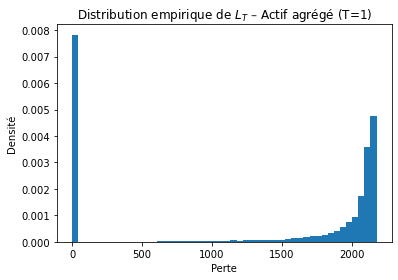

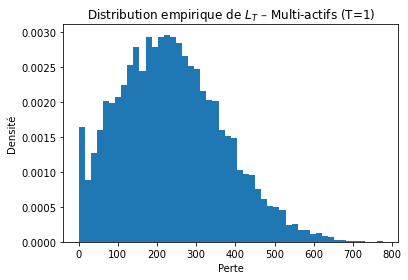

In [35]:
T = 1

# Actif agrégé
plt.figure()
plt.hist(dist_agg[T], bins=50, density=True)
plt.title("Distribution empirique de $L_T$ – Actif agrégé (T=1)")
plt.xlabel("Perte")
plt.ylabel("Densité")
plt.show()

# Multi-actifs
plt.figure()
plt.hist(dist_multi[T], bins=50, density=True)
plt.title("Distribution empirique de $L_T$ – Multi-actifs (T=1)")
plt.xlabel("Perte")
plt.ylabel("Densité")
plt.show()


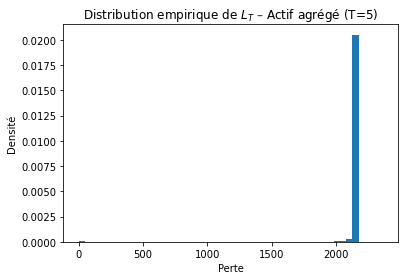

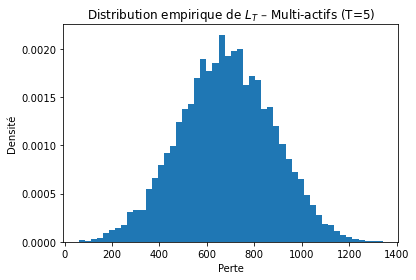

In [36]:
T = 5

# Actif agrégé
plt.figure()
plt.hist(dist_agg[T], bins=50, density=True)
plt.title("Distribution empirique de $L_T$ – Actif agrégé (T=5)")
plt.xlabel("Perte")
plt.ylabel("Densité")
plt.show()

# Multi-actifs
plt.figure()
plt.hist(dist_multi[T], bins=50, density=True)
plt.title("Distribution empirique de $L_T$ – Multi-actifs (T=5)")
plt.xlabel("Perte")
plt.ylabel("Densité")
plt.show()



Les distributions empiriques de la perte cumulée L_T mettent clairement en évidence des comportements très différents selon l’approche retenue.


À horizon fixé, l’actif agrégé génère une distribution fortement concentrée sur des pertes élevées, avec une dynamique quasi binaire : soit aucune perte, soit une perte proche du maximum, ce qui explique des niveaux de VaR très élevés. À l’inverse, l’approche multi-actifs produit une distribution plus étalée et continue, traduisant les effets de diversification et une propagation graduelle des pertes entre actifs.

Lorsque l’horizon T augmente, ces différences se renforcent : la distribution de l’actif agrégé évolue peu, les pertes extrêmes étant atteintes très tôt, ce qui conduit à une saturation rapide du risque, tandis que la distribution multi-actifs se décale progressivement vers la droite, reflétant une accumulation intertemporelle réaliste des pertes. Globalement, l’approche agrégée apparaît très conservatrice mais peu sensible à l’horizon, alors que l’approche multi-actifs offre une vision plus nuancée et économiquement cohérente du risque de portefeuille.